GROUP NUMBER: 3

GROUP MEMBER: A.HEMANT KUMAAR, JACK LICHWA , PRITHIKA K

# **PIT STOP ANALYSIS PROJECT**

## **PROJECT BACKGROUND**

Formula 1 (F1) is the pinnacle of motorsport, combining elite driver skill with cutting-edge engineering. A critical and often race-deciding element of F1 strategy is the **pit stop** — a brief pause in which a team changes tires, makes aerodynamic adjustments, or responds to race incidents. The duration of a pit stop, even down to fractions of a second, can determine whether a driver retains or loses a podium position.

For top-finishing drivers (those who finish in the top 3), pit stop strategy is especially high-stakes. A slow stop can cost a driver a podium; an efficiently timed stop can vault them ahead of a competitor. Understanding what factors influence the **maximum pit stop duration** experienced by top 3 finishers has implications for race engineering, team strategy optimization, and performance analytics.

This study investigates whether historical race data, tire information, and race conditions can be used to predict the maximum pit stop duration among the top three drivers in a Formula 1 race.

## **DATASET**

**Source**: All datasets come from Kaggle: "Formula 1 Race Data" by jtrotman. https://www.kaggle.com/datasets/jtrotman/formula-1-race-data?resource=download&select=lap_times.csv

They contain historical Formula 1 data from 1950 onwards, including race results, circuits, drivers, constructors, lap times, pit stops, qualifying, sprint results, and season standings.

**Key Variable**:
At this stage, we are exploring all variables from the pit stops, races, circuits, drivers, constructors, lap times, qualifying, and results datasets. Final selection of key predictor variables will be based on further analysis and exploratory data analysis (EDA), including correlations, distributions, and relevance to pit stop duration.

**Data Type**: The datasets include a mix of numeric, categorical, ordinal, and datetime variables:

- Numeric: milliseconds, lap, round, year, alt, points, positionOrder
- Categorical: driverId, surname, constructorId, constructor name, circuitId, location, country, status
- Ordinal: stop (pit stop sequence), grid position, and finishing positions
- Datetime: race dates (races.date) and driver birth dates (drivers.dob)

These variables provide the foundation for preprocessing and exploratory analysis to identify potential predictors for pit stop duration.

## LAB 4

### Problem Statement

**Modeling Question**: Can we predict whether a Formula 1 driver will finish in the **top 3 (podium)** using race context, circuit characteristics, qualifying pace, and pit-stop features?

**Response Variable**: `top3_finish` — binary classification target
- `1` = Driver finished in positions 1, 2, or 3  
- `0` = Driver finished outside the top 3

**Predictor Variables**:

| Feature Group | Variables |
|---|---|
| Race context | `race_year`, `race_circuit`, `race_country`, `race_altitude_m` |
| Driver / Team | `team`, `race_start_position`, `qualifying_position`, `quali_lap_time_s`, `laps_completed` |
| Driver pit stops | `driver_pit_stops_count`, `driver_pit_stops_avg_duration_s` |
| Race-level pit stops | `race_pit_stops_count`, `race_pit_stops_avg_duration_s`, `race_pit_stops_max_duration_s`, `race_pit_stops_min_duration_s`, `race_avg_laps_before_pit_stop` |

**Dataset**: `f1_driver_classification_data.csv` — 5,970 driver-race observations across multiple F1 seasons.  
Each row represents one driver's performance summary in one Grand Prix.

**Lab 4 Focus**: Lab 3 applied a nonlinear RBF SVM. This lab extends that work by:
1. Applying **Linear SVM** (the approach recommended when revisiting a nonlinear SVM baseline)
2. Comparing Linear vs RBF SVM kernels with full evaluation metrics
3. Fitting a **Logistic Regression** model as an interpretable benchmark
4. Comparing all methods using Accuracy, Precision, Recall, F1-Score, ROC curves, and Confusion Matrices

### Setup and Data Loading

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, RocCurveDisplay
)

# Shorthand following Chapter 9 lab convention
roc_curve = RocCurveDisplay.from_estimator

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


In [52]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS'
    '/refs/heads/main/data/f1_driver_classification_data.csv'
)

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:')
counts = df['top3_finish'].value_counts().sort_index()
print(counts.rename(index={0: 'Not Top 3 (0)', 1: 'Top 3 (1)'}))
print(f'\nPositive class rate: {df["top3_finish"].mean():.2%}')
display(df.head(3))

Dataset shape: (5970, 17)

Class distribution:
top3_finish
Not Top 3 (0)    5052
Top 3 (1)         918
Name: count, dtype: int64

Positive class rate: 15.38%


,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,2.0,23.3195,45.0,24.280365,37.856,16.867,23.055556,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,2.0,23.2130,45.0,24.280365,37.856,16.867,23.055556,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,2.0,25.1090,45.0,24.280365,37.856,16.867,23.055556,1


### Data Preparation


In [53]:
y = df['top3_finish']
X = df.drop(columns=['top3_finish'])

# One-hot encode categoricals (consistent with Lab 3 approach)
X_enc = pd.get_dummies(X, columns=['race_circuit', 'race_country', 'team'], drop_first=True)
print(f'Shape after encoding: {X_enc.shape}')

# Train / test split 
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize 
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')


Shape after encoding: (5970, 100)
Train: (4776, 100) | Test: (1194, 100)


### Task 1 — Apply Linear SVM

We first train a baseline (C=1), run 5-fold stratified cross-validation, then use GridSearchCV to find the best `C`.

In [54]:
# Baseline Linear SVM (C=1) — fit directly on scaled data, like Chapter 9 lab
linear_baseline = SVC(kernel='linear', C=1, class_weight='balanced', random_state=42)
linear_baseline.fit(X_train_s, y_train)
y_pred_lin_base = linear_baseline.predict(X_test_s)

print('=== Linear SVM Baseline (C=1) ===')
print(classification_report(y_test, y_pred_lin_base,
                             target_names=['Not Top 3', 'Top 3'], zero_division=0))

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(linear_baseline, X_train_s, y_train,
                            scoring='f1', cv=cv, n_jobs=-1)
print(f'5-Fold CV F1 scores: {np.round(cv_scores, 4)}')


=== Linear SVM Baseline (C=1) ===
              precision    recall  f1-score   support

   Not Top 3       0.98      0.83      0.90      1010
       Top 3       0.49      0.90      0.63       184

    accuracy                           0.84      1194
   macro avg       0.73      0.86      0.76      1194
weighted avg       0.90      0.84      0.86      1194

5-Fold CV F1 scores: [0.6334 0.6333 0.613  0.6569 0.6601]


In [55]:
# GridSearchCV — tune C, refit=True so best_estimator_ is ready immediately
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_linear = GridSearchCV(
    SVC(kernel='linear', class_weight='balanced', random_state=42),
    param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    scoring='f1',
    refit=True,
    cv=kfold,
    n_jobs=-1
)
grid_linear.fit(X_train_s, y_train)

best_C_linear = grid_linear.best_params_['C']
print(f'Best C: {best_C_linear}  |  Best CV F1: {grid_linear.best_score_:.4f}')

best_linear_svc = grid_linear.best_estimator_
y_pred_lin_tuned = best_linear_svc.predict(X_test_s)

print('\n=== Linear SVM (Tuned) ===')
print(classification_report(y_test, y_pred_lin_tuned,
                             target_names=['Not Top 3', 'Top 3'], zero_division=0))



Best C: 1  |  Best CV F1: 0.6408

=== Linear SVM (Tuned) ===
              precision    recall  f1-score   support

   Not Top 3       0.98      0.83      0.90      1010
       Top 3       0.49      0.90      0.63       184

    accuracy                           0.84      1194
   macro avg       0.73      0.86      0.76      1194
weighted avg       0.90      0.84      0.86      1194



GridSearchCV selected **C=1** (CV F1 = 0.64), meaning the default regularization strength was already near-optimal.

The tuned model shows a clear precision/recall trade-off driven by `class_weight='balanced'`:
- **Recall = 0.90** — the model catches 90% of actual Top 3 finishes, which is the priority in an imbalanced setting
- **Precision = 0.49** — roughly half of predicted Top 3 finishes are false alarms (drivers who did not podium)
- **F1 = 0.63** — reflects this imbalance between precision and recall
- **Accuracy = 0.84** is misleading here: a model that always predicts "Not Top 3" would already score ~85%, so accuracy alone is not a useful metric for this problem

### Task 2 — Compare Linear vs RBF SVM

The **RBF (Radial Basis Function)** kernel allows to capture curved, nonlinear decision boundaries that a linear SVM cannot.


In [56]:
# RBF SVM — tune C and gamma via GridSearchCV (same setup as linear, fair comparison)
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_rbf = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.5, 1, 2, 3, 4]},
    scoring='f1',
    refit=True,
    cv=kfold,
    n_jobs=-1
)
grid_rbf.fit(X_train_s, y_train)

print(f'Best params: {grid_rbf.best_params_}  |  Best CV F1: {grid_rbf.best_score_:.4f}')

rbf_svc = grid_rbf.best_estimator_
y_pred_rbf = rbf_svc.predict(X_test_s)

print('\n=== RBF SVM (Tuned) ===')
print(classification_report(y_test, y_pred_rbf,
                             target_names=['Not Top 3', 'Top 3'], zero_division=0))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rbf = cross_val_score(rbf_svc, X_train_s, y_train, scoring='f1', cv=cv, n_jobs=-1)
print(f'5-Fold CV F1: {cv_rbf.mean():.4f} ± {cv_rbf.std():.4f}')

Best params: {'C': 1, 'gamma': 0.5}  |  Best CV F1: 0.4205

=== RBF SVM (Tuned) ===
              precision    recall  f1-score   support

   Not Top 3       0.90      0.94      0.92      1010
       Top 3       0.57      0.42      0.49       184

    accuracy                           0.86      1194
   macro avg       0.73      0.68      0.70      1194
weighted avg       0.85      0.86      0.85      1194

5-Fold CV F1: 0.4558 ± 0.0270


**RBF SVM Results**

Even after tuning `C` and `gamma` on the same scaled data, RBF underperforms the linear kernel:

| Metric | Linear SVM (Tuned) | RBF SVM (Tuned) |
|---|---|---|
| Best params | C=1 | C=1, γ=0.5 |
| CV F1 (tuning) | 0.64 | 0.42 |
| Precision (Top 3) | 0.49 | 0.57 |
| Recall (Top 3) | 0.90 | 0.42 |
| F1 (Top 3) | 0.63 | 0.49 |
| 5-Fold CV F1 | 0.64 | 0.46 ± 0.03 |

- **Recall = 0.42** — the RBF model misses more than half of all actual Top 3 finishes
- **CV F1 = 0.46 ± 0.03** — higher variance than linear, indicating less stable generalization
- The RBF's added complexity does not help here

 The top-3 outcome appears to be well-separated by a linear boundary (grid position, qualifying time are strong linear predictors), so the RBF kernel's nonlinear flexibility is unnecessary and adds noise.

### Task 3 — Fit Logistic Regression

Logistic Regression models the **log-odds** of a Top 3 finish as a linear combination of features.

In [61]:
# Logistic Regression with GridSearchCV
grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid={'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']},
    scoring='f1',
    refit=True,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1
)
grid_lr.fit(X_train_s, y_train)

print(f'Best LR params: {grid_lr.best_params_}')
print(f'Best CV F1:     {grid_lr.best_score_:.4f}')

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_s)

print('\n=== Logistic Regression (Tuned) ===')
print(classification_report(y_test, y_pred_lr,
                             target_names=['Not Top 3', 'Top 3'], zero_division=0))

cv_lr = cross_val_score(
    best_lr, X_train_s, y_train, scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), n_jobs=-1
)
print(f'5-Fold CV F1: {cv_lr.mean():.4f}')

Best LR params: {'C': 100, 'solver': 'lbfgs'}
Best CV F1:     0.6416

=== Logistic Regression (Tuned) ===
              precision    recall  f1-score   support

   Not Top 3       0.97      0.84      0.90      1010
       Top 3       0.50      0.88      0.64       184

    accuracy                           0.85      1194
   macro avg       0.74      0.86      0.77      1194
weighted avg       0.90      0.85      0.86      1194

5-Fold CV F1: 0.6401


**Logistic Regression Results**

- **Best C=100** — very little regularization needed, meaning the full OHE feature set is informative rather than noisy
- **Recall = 0.88** — catches the majority of actual Top 3 finishes, the priority in an imbalanced setting
- **Precision = 0.50** — about half of predicted Top 3 finishes are correct
- **F1 = 0.64, CV F1 = 0.64** — stable across folds

An added advantage over SVM: Logistic Regression natively produces calibrated probabilities, making it useful when a confidence score is needed rather.

### Task 4 — Compare All Methods

We compare all models on four metrics computed on the held-out test set:

| Metric | What it measures |
|---|---|
| **Accuracy** | Fraction of all predictions that are correct |
| **Precision (Top 3)** | Of all predicted Top 3, what fraction actually finished Top 3 |
| **Recall (Top 3)** | Of all actual Top 3 finishes, what fraction were predicted correctly |
| **F1-Score (Top 3)** | Harmonic mean of Precision and Recall — balances both, critical under class imbalance |

Because the dataset is imbalanced (~15% positive), **F1-Score is the primary ranking metric**. 



=== Model Performance Comparison (Test Set) ===


,Accuracy,Precision (Top 3),Recall (Top 3),F1-Score (Top 3)
Logistic Regression,0.8451,0.4985,0.8804,0.6365
Linear SVM (Baseline C=1),0.8384,0.4867,0.8967,0.6310
Linear SVM (Tuned),0.8384,0.4867,0.8967,0.6310
RBF SVM (Lab 3 Best),0.8618,0.5693,0.4239,0.4860


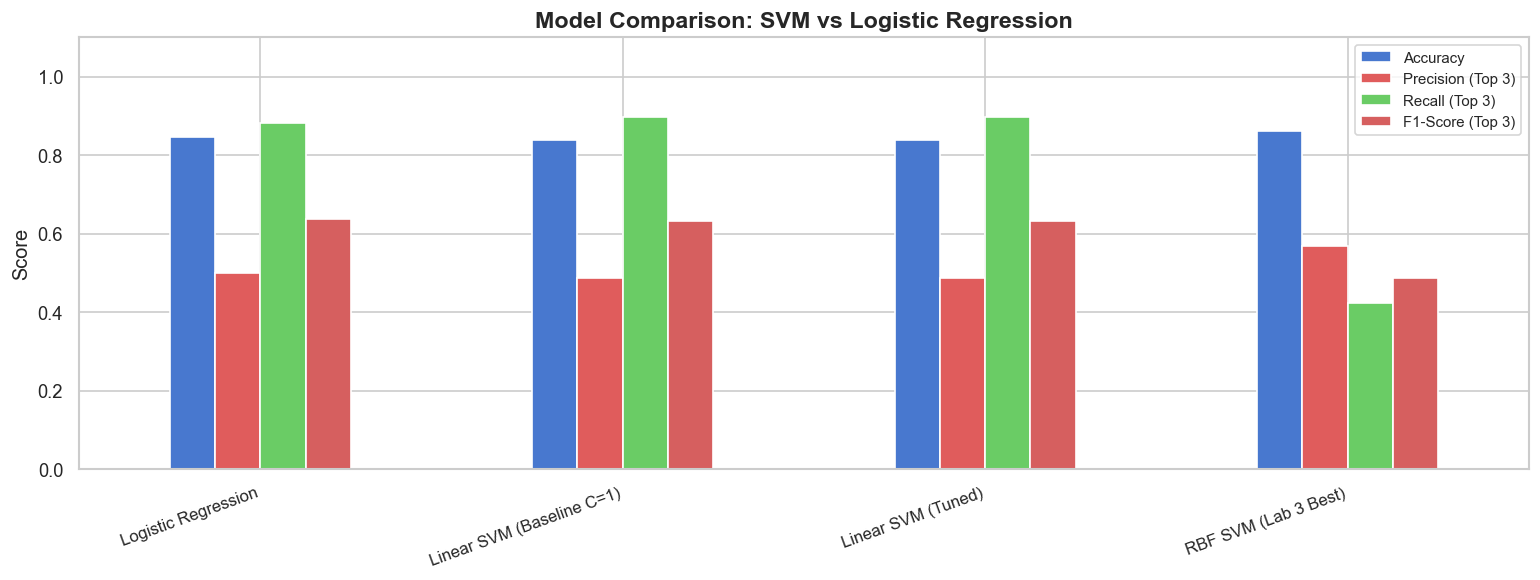

In [58]:
def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Top 3)': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Top 3)': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score (Top 3)': f1_score(y_true, y_pred, zero_division=0),
    }

model_results = {
    'Linear SVM (Baseline C=1)': evaluate_model(y_test, y_pred_lin_base),
    'Linear SVM (Tuned)':        evaluate_model(y_test, y_pred_lin_tuned),
    'RBF SVM (Lab 3 Best)':      evaluate_model(y_test, y_pred_rbf),
    'Logistic Regression':       evaluate_model(y_test, y_pred_lr),
}

comparison_df = (
    pd.DataFrame(model_results).T
    .sort_values('F1-Score (Top 3)', ascending=False)
)

print('=== Model Performance Comparison (Test Set) ===')
display(comparison_df.round(4))

ax = comparison_df.plot(kind='bar', figsize=(13, 5), edgecolor='white',
                        color=['#4878cf', '#e05c5c', '#6acc65', '#d65f5f'])
ax.set_title('Model Comparison: SVM vs Logistic Regression',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

**Comparison Interpretation**

Logistic Regression and both Linear SVM models perform nearly identically — all three achieve F1 ≈ 0.63–0.64 and recall ≈ 0.88–0.90, confirming that a linear decision boundary is well-suited to this problem. 

The RBF SVM stands out as the outlier: it has the highest accuracy (0.86) and precision (0.57), but its recall collapses to 0.42 — meaning it misses more than half of all actual Top 3 finishes. Since accuracy is misleading under class imbalance (~85% of drivers do not finish Top 3), F1 is the right metric, and by that measure RBF ranks last.

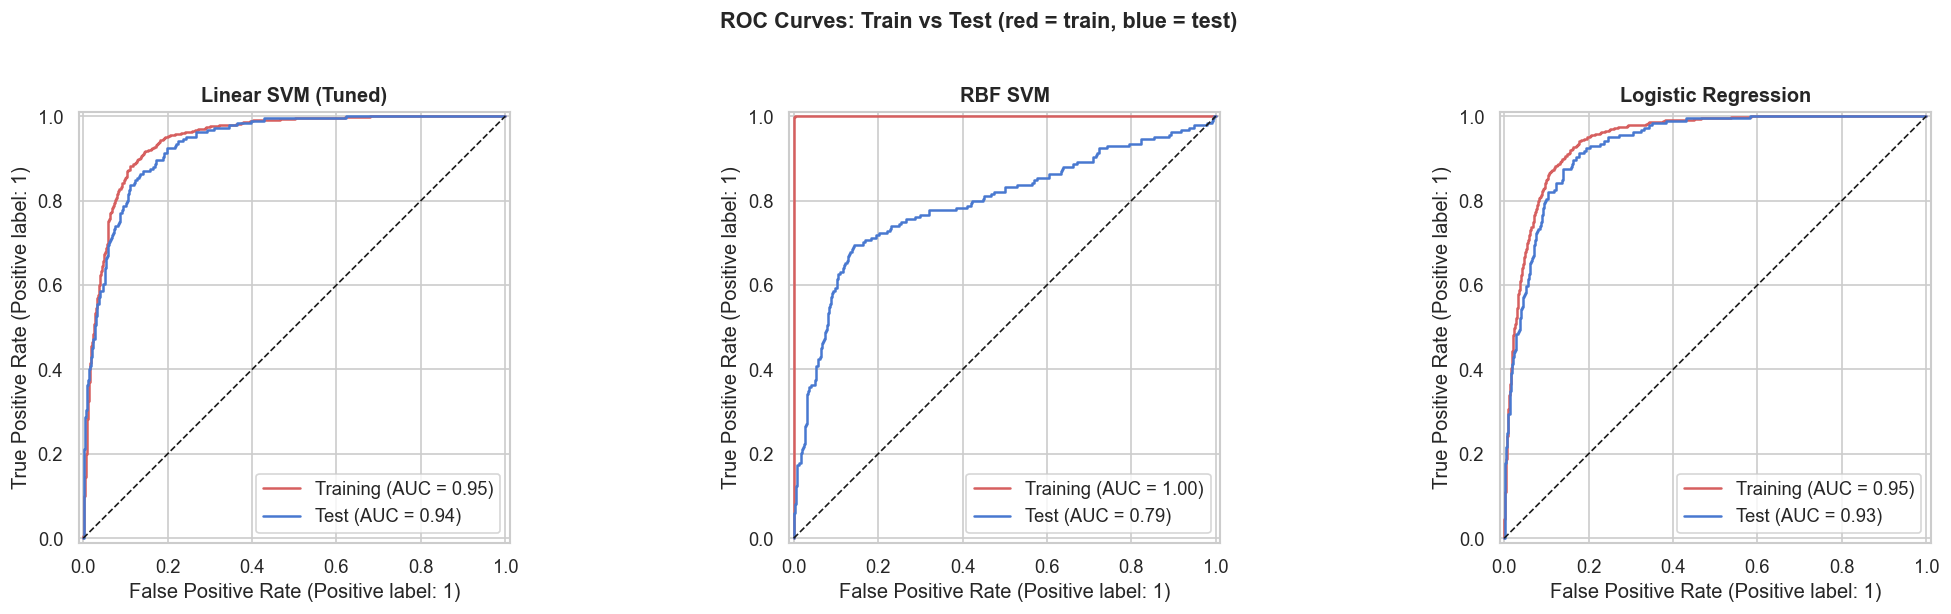

In [59]:
# ROC Curves — training vs test per model (Chapter 9 lab pattern)
roc_models = {
    'Linear SVM (Tuned)':  best_linear_svc,
    'RBF SVM':             rbf_svc,
    'Logistic Regression': best_lr,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, roc_models.items()):
    for X_, y_, color, label in zip(
        (X_train_s, X_test_s),
        (y_train,   y_test),
        ('r', 'b'),
        ('Training', 'Test')
    ):
        roc_curve(model, X_, y_, name=label, color=color, ax=ax)
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('ROC Curves: Train vs Test (red = train, blue = test)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**ROC Interpretation**

The train vs test gap:

- **Linear SVM** (AUC train=0.95, test=0.94) — virtually no gap, the model generalizes well with no overfitting
- **Logistic Regression** (AUC train=0.95, test=0.93) — same pattern, near-identical to linear SVM on both curves
- **RBF SVM** (AUC train=1.00, test=0.79) — the training curve is perfect, but test AUC drops sharply by 0.21 points, a clear sign of overfitting; the model memorizes the training data rather than learning a generalizable pattern

The RBF result explains why its F1 score was low, RBF model that does not generalize. Linear SVM and Logistic Regression both achieve test AUC ≈ 0.94, confirming they are the better choices for this dataset.

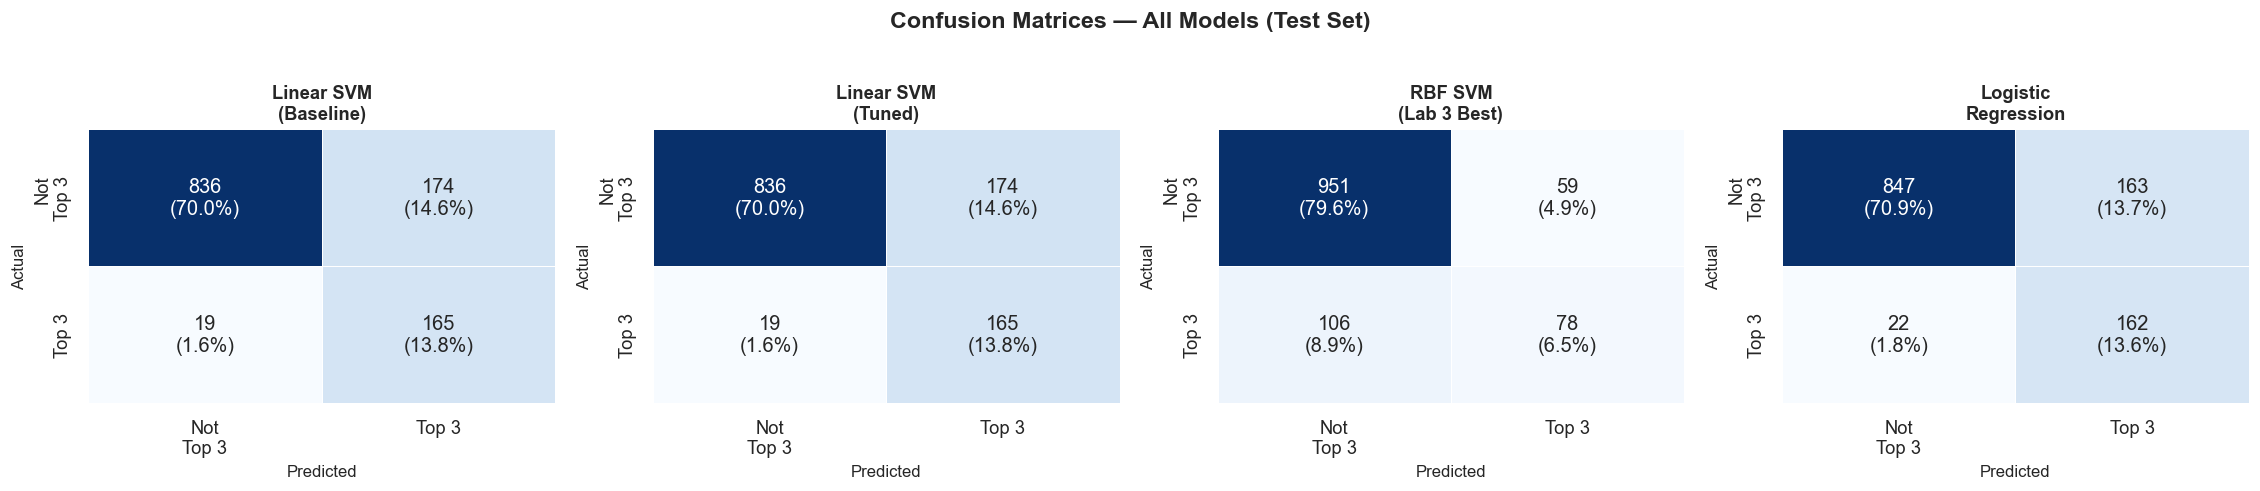

In [60]:
# Confusion Matrices — all four models side by side
model_preds = {
    'Linear SVM\n(Baseline)': y_pred_lin_base,
    'Linear SVM\n(Tuned)':    y_pred_lin_tuned,
    'RBF SVM\n(Lab 3 Best)':  y_pred_rbf,
    'Logistic\nRegression':   y_pred_lr,
}

fig, axes = plt.subplots(1, 4, figsize=(19, 4))

for ax, (name, y_pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    # Compute per-cell percentages for annotations
    cm_pct = cm.astype(float) / cm.sum() * 100
    labels = np.array([
        [f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
        for row_v, row_p in zip(cm, cm_pct)
    ])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Not\nTop 3', 'Top 3'],
                yticklabels=['Not\nTop 3', 'Top 3'],
                cbar=False, linewidths=0.5)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices — All Models (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- **Linear SVM Baseline = Linear SVM Tuned** — the matrices are identical (836/174/19/165), confirming that tuning C made no practical difference; the default C=1 was already optimal
- **Linear SVM & Logistic Regression** — both correctly catch ~165/162 of 184 actual Top 3 finishes (missing only 19–22), but at the cost of ~163–174 false alarms among the Not Top 3 drivers
- **RBF SVM** — the opposite pattern: only 59 false alarms (far fewer than the others) but misses 106 of 184 actual Top 3 finishes (57%)

In practical terms, if the goal is to flag likely Top 3 drivers before a race, Linear SVM and Logistic Regression are far safer — they miss only ~10% of actual podium finishers, whereas RBF would miss more than half.